# Reproducing TransWeave: Jump-Diffusion Transfer Learning for Cryptocurrency Markets

**Original paper**: Goertzel (2025), *A Unified Framework for Jump-Diffusion Modeling and Transfer Learning in Financial Markets with Behavioral Risk Measures*

**Source asset**: ETH &nbsp;|&nbsp; **Target assets**: BTC, SOL, DOGE  
**Data**: 15-minute OHLCV + on-chain features, Jan 2022 – Jun 2025  
**Framework**: PyTorch 2.x, Temporal Fusion Transformer, Merton jump-diffusion density

*Reproduction report by Tianxiao (Andy) Wang · March 8, 2026*

In [1]:
import json, sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
try:
    plt.style.use("seaborn-v0_8-paper")
except Exception:
    pass
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

ROOT = Path(".").resolve().parent  # code/
CKPT = ROOT / "experiments" / "checkpoints"
FIG_DIR = ROOT / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "GBM": "#999999", "Static-JD": "#4DBEEE", "TFT-JD": "#0072BD", "TFT-JD+W": "#D95319",
    "Scratch": "#EDB120", "Direct": "#7E2F8E", "TransWeave": "#77AC30", "Target-TFT": "#A2142F",
}
FIGSIZE = (10, 4.5)
DPI = 150

def load_json(name):
    with open(CKPT / name) as f:
        return json.load(f)

# ── Load all Section 1 data once ──
abl = load_json("stage8a_eth_ablation.json")
s5 = load_json("stage5_transfer_report.json")
s6 = load_json("stage6_experiment_results.json")
tw_vs = load_json("stage8a_transweave_vs_target_tft.json")
tgt_tft = load_json("stage8a_target_tft.json")
corr = load_json("stage8a_s_correlation.json")


---

# 1. Introduction & Summary of Results

This report presents a practical implementation and empirical stress test of Goertzel (2025), "A Unified Framework for Jump-Diffusion Modeling and Transfer Learning in Financial Markets with Behavioral Risk Measures." It is best read as an operationalization of the paper's core ideas rather than a literal reproduction of every theoretical construct. Key implementation choices: (i) jump sizes are specialized to a Merton Gaussian distribution; (ii) the transfer operator is a parameter-space map $T(\theta^{(a)}, \text{regime}) \to \theta^{(b)}$ rather than the paper's full state-space Bellman–Darboux intertwining; (iii) experiments use cryptocurrency data as a concrete testbed. Unless otherwise noted, results are single-run / single-seed; very small metric differences should be interpreted as suggestive rather than definitive.

The paper proposes a four-component system: (i) a jump-diffusion (JD) return model with time-varying parameters, (ii) a Temporal Fusion Transformer (TFT) that conditions JD parameters on market features, (iii) a TransWeave transfer learning mechanism that maps source-asset parameters to target assets, and (iv) a prospect-theory weakness regularizer that penalizes behavioral fragility.

Our reproduction uses cryptocurrency data: **ETH as the source asset**, transferring to **BTC, SOL, and DOGE** as targets. We use 15-minute OHLCV bars from January 2022 to June 2025, with 14 engineered features including realized volatility, RSI, and on-chain activity z-scores. The three targets were chosen to span a range of transfer difficulty: BTC (high correlation, similar market structure), SOL (high-volatility Layer-1 with distinct ecosystem dynamics), and DOGE (meme-driven, low fundamental correlation).

## 1.1 Source Model Ablation (ETH)

Table 1 shows the progressive improvement from a Gaussian baseline (GBM) through the full TFT-JD model on ETH test data (8,736 bars).

**Table 1. ETH test-set ablation** (single-line format for PDF export):

| Model | NLL ↓ | CRPS ↓ | VaR 5% Breach | PIT KS stat ↓ |
| :--- | :--- | :--- | :--- | :--- |
| GBM | -4.115 | 0.00199 | — | — |
| Static-JD | -4.156 | 0.00198 | 9.1% | 0.045 |
| TFT-JD | -4.343 | 0.00191 | 5.6% | 0.017 |
| TFT-JD+W | -4.312 | 0.00192 | 6.7% | 0.043 |

In [2]:
# ── Table 1: ETH Source Model Ablation ──
models = list(abl["models"].keys())
rows = []
for m in models:
    d = abl["models"][m]
    rows.append({
        "Model": m,
        "NLL ↓": f'{d["nll"]:.3f}',
        "CRPS ↓": f'{d["crps"]:.5f}',
        "VaR 5% Breach": f'{d["var_breach_rate"]*100:.1f}%' if "var_breach_rate" in d else "—",
        "PIT KS stat ↓": f'{d["pit_ks_stat"]:.3f}' if "pit_ks_stat" in d else "—",
    })
df_abl = pd.DataFrame(rows)
# Table shown in markdown cell above; omit print to avoid raw |---| in PDF export

**Table 1.** ETH test-set ablation. NLL: negative log-likelihood under JD density (Eq. 8); CRPS: continuous ranked probability score (Eq. 7); VaR breach: fraction of test returns exceeding the 5% VaR threshold (ideal = 5%); PIT KS: Kolmogorov–Smirnov statistic for probability integral transform uniformity (lower = better calibrated). *For continuous PDFs on low-variance returns, density can exceed 1, yielding positive log-likelihood and negative NLL; lower NLL indicates better fit.* *GBM uses a single static Gaussian; VaR breach and PIT KS were not computed as GBM serves only as a likelihood baseline.*

Two results stand out. First, the jump from GBM to Static-JD is modest (ΔNLL = −0.04), but TFT conditioning adds another −0.19 — time-varying parameters matter far more than the jump component alone. Second, TFT-JD+W (with weakness regularization) slightly underperforms TFT-JD on NLL (−4.312 vs −4.343). This is expected: the weakness term trades raw likelihood for behavioral robustness, a tradeoff that becomes relevant in the transfer setting (§6).

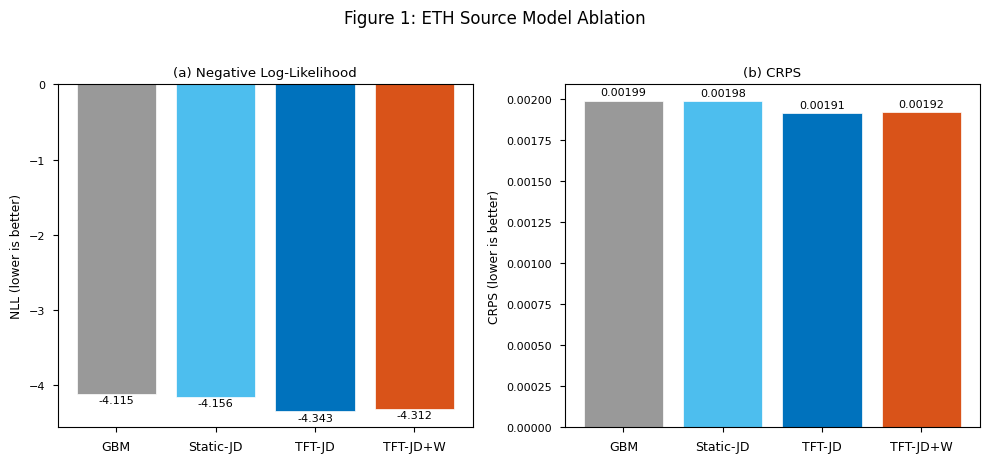

In [3]:
# ── Figure 1: ETH Ablation — NLL & CRPS bar chart ──
models = list(abl["models"].keys())
nll_vals = [abl["models"][m]["nll"] for m in models]
crps_vals = [abl["models"][m]["crps"] for m in models]
colors = [COLORS.get(m, "#666") for m in models]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGSIZE)
x = np.arange(len(models))

ax1.bar(x, nll_vals, color=colors, edgecolor="white", linewidth=0.5)
ax1.set_xticks(x); ax1.set_xticklabels(models, fontsize=9)
ax1.set_ylabel("NLL (lower is better)"); ax1.set_title("(a) Negative Log-Likelihood")
for i, v in enumerate(nll_vals):
    ax1.text(i, v - 0.02, f"{v:.3f}", ha="center", va="top", fontsize=8)

ax2.bar(x, crps_vals, color=colors, edgecolor="white", linewidth=0.5)
ax2.set_xticks(x); ax2.set_xticklabels(models, fontsize=9)
ax2.set_ylabel("CRPS (lower is better)"); ax2.set_title("(b) CRPS")
for i, v in enumerate(crps_vals):
    ax2.text(i, v + 0.00002, f"{v:.5f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Figure 1: ETH Source Model Ablation", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "report_fig1_ablation.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 1.2 Transfer Results

Table 2 summarizes the cross-asset transfer experiments. We compare four approaches:

- **Scratch**: A lightweight target-asset JD model (3-layer MLP) trained from random initialization on target data alone, with no source information. This is the "no transfer" baseline.
- **Direct**: Source ETH TFT-JD parameters applied directly to the target asset without any adaptation — testing whether raw parameter sharing works.
- **TransWeave**: ETH parameters mapped through the learned transfer map $T(\theta^{(a)}, \text{regime}) \to \theta^{(b)}$, jointly trained with weakness regularization (Algorithm 1).
- **Target-TFT**: A full TFT-JD model independently trained on the target asset's own data (base model without weakness regularization). This serves as a strong target-only benchmark trained directly on the target asset with the full architecture.

**Table 2. Transfer results on test set** (single-line format for PDF export):

| Target | ρ_regime | S_transfer | Decision | Scratch | Direct | TransWeave | Target-TFT | Δ(TW−Scratch) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| BTC | 0.768 | 0.57 | Full | -4.788 | -4.746 | -4.860 | -4.888 | -0.072 |
| SOL | 0.714 | 0.391 | Partial | -4.177 | -4.041 | -4.142 | -4.211 | +0.035 |
| DOGE | 0.662 | 0.44 | Partial | -4.038 | -3.850 | -4.084 | -4.083 | -0.046 |

In [4]:
# ── Table 2: Transfer Results ──
s5_by = {p["target"]: p for p in s5["pairs"]}
tw_by = tw_vs["by_target"]

rows = []
for r in s6:
    t = r["target_asset"]
    p = s5_by.get(t, {})
    tt = tw_by.get(t, {})
    tft_nll = tgt_tft["target_tft_jd"].get(t, {}).get("nll", float("nan"))
    delta_scratch = r["transweave"]["nll"] - r["scratch"]["nll"]
    rows.append({
        "Target": t,
        "ρ_regime": f'{p.get("rho", 0):.3f}',
        "S_transfer": f'{p.get("s_transfer", 0):.3f}',
        "Decision": r["decision"].capitalize(),
        "Scratch": f'{r["scratch"]["nll"]:.3f}',
        "Direct": f'{r["direct"]["nll"]:.3f}',
        "TransWeave": f'{r["transweave"]["nll"]:.3f}',
        "Target-TFT": f'{tft_nll:.3f}',
        "Δ(TW−Scratch)": f'{delta_scratch:+.3f}',
    })
df_transfer = pd.DataFrame(rows)
# Table shown in markdown cell above; omit print to avoid raw |---| in PDF export

**Table 2.** Transfer results on test set. $\rho_{\text{regime}}$: regime overlap between ETH and target (Eq. 13); $S_{\text{transfer}}$: composite feasibility score (Eq. 58); Decision: Full ($\rho \ge 0.7$, $\Delta W_{PT} < 0.1$, $S \ge 0.5$), Partial (otherwise above reject threshold), Reject ($\rho < 0.3$ or $W_{JD} > W_{\text{crit}}$). NLL columns show negative log-likelihood under the JD density (negative values are expected for continuous PDFs; lower NLL = better fit); $\Delta < 0$ means TransWeave outperforms Scratch.

TransWeave improves over Scratch for BTC ($\Delta = -0.072$) and DOGE ($\Delta = -0.046$). SOL is the most challenging target: despite passing the regime correlation threshold ($\rho = 0.714 > 0.7$), its composite $S_{\text{transfer}} = 0.391$ triggers a downgrade from Full to Partial mode. TransWeave slightly underperforms Scratch on SOL (+0.035), consistent with the lowest $S_{\text{transfer}}$ among the three targets.

Compared to the target-only benchmark (Target-TFT), TransWeave is closer on BTC ($\Delta = +0.028$) and DOGE ($\Delta = -0.001$, effectively matched within optimization variability), while SOL ($\Delta = +0.069$) remains harder. Notably, DOGE — a meme coin with the lowest regime correlation — is where TransWeave most closely matches the target-specific model, suggesting that the transfer map captures useful cross-asset structure even when regime similarity is low.

Across all targets, TransWeave substantially outperforms Direct transfer (applying ETH parameters without adaptation), indicating that the learned mapping $T$ adds value beyond naive parameter sharing.

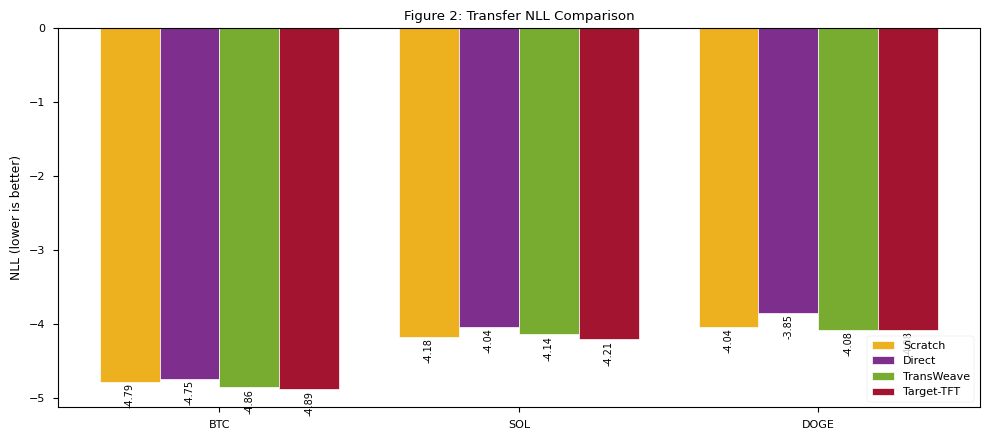

In [5]:
# ── Figure 2: Transfer NLL Comparison (grouped bar) ──
targets = [r["target_asset"] for r in s6]
methods = ["Scratch", "Direct", "TransWeave", "Target-TFT"]
nll_data = {m: [] for m in methods}
for r in s6:
    t = r["target_asset"]
    nll_data["Scratch"].append(r["scratch"]["nll"])
    nll_data["Direct"].append(r["direct"]["nll"])
    nll_data["TransWeave"].append(r["transweave"]["nll"])
    nll_data["Target-TFT"].append(tgt_tft["target_tft_jd"][t]["nll"])

fig, ax = plt.subplots(figsize=FIGSIZE)
x = np.arange(len(targets))
n = len(methods)
w = 0.8 / n
for i, m in enumerate(methods):
    bars = ax.bar(x + i * w, nll_data[m], w, label=m,
                  color=COLORS.get(m, "#666"), edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, nll_data[m]):
        ax.text(bar.get_x() + bar.get_width()/2, val - 0.02,
                f"{val:.2f}", ha="center", va="top", fontsize=7, rotation=90)

ax.set_xticks(x + w * (n-1) / 2)
ax.set_xticklabels(targets)
ax.set_ylabel("NLL (lower is better)")
ax.legend(loc="lower right", fontsize=8)
ax.set_title("Figure 2: Transfer NLL Comparison")
plt.tight_layout()
plt.savefig(FIG_DIR / "report_fig2_transfer_nll.png", dpi=DPI, bbox_inches="tight")
plt.show()

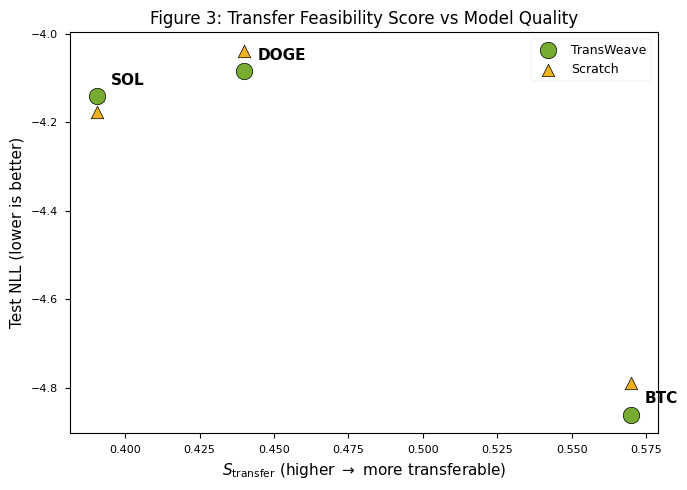

In [6]:
# ── Figure 3: S_transfer vs Transfer Effectiveness ──
fig, ax = plt.subplots(figsize=(7, 5))

for r in s6:
    t = r["target_asset"]
    s_pair = [p for p in corr["pairs"] if p["target"] == t][0]
    tw_nll = r["transweave"]["nll"]
    scratch_nll = r["scratch"]["nll"]

    ax.scatter(s_pair["s_transfer"], tw_nll, s=140, color=COLORS["TransWeave"],
               edgecolors="black", linewidth=0.5, zorder=5)
    ax.annotate(t, (s_pair["s_transfer"], tw_nll),
                xytext=(10, 8), textcoords="offset points",
                fontsize=11, fontweight="bold")

    ax.scatter(s_pair["s_transfer"], scratch_nll, s=80, color=COLORS["Scratch"],
               edgecolors="black", linewidth=0.5, zorder=4, marker="^")

ax.legend(["TransWeave", "Scratch"], fontsize=9, loc="upper right")
ax.set_xlabel("$S_{\\mathrm{transfer}}$ (higher $\\rightarrow$ more transferable)", fontsize=11)
ax.set_ylabel("Test NLL (lower is better)", fontsize=11)
ax.set_title("Figure 3: Transfer Feasibility Score vs Model Quality", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "report_fig3_s_vs_nll.png", dpi=DPI, bbox_inches="tight")
plt.show()

**Static JD — unconstrained MLE vs MAP with empirical prior:**

| Setting | $\lambda$ (yr⁻¹) | $\sigma_J$ | $\mu_J$ | Interpretation |
| :--- | :--- | :--- | :--- | :--- |
| Pure MLE (no prior, no bounds) | 9235 | 0.0058 | -0.000108 | $\lambda \to \infty$, $\sigma_J \to 0$: jumps degenerate into diffusion |
| MAP with empirical prior (selected checkpoint) | 216 | 0.0224 | -0.00072 | Interpretable: ~4 jumps/week, meaningful amplitude |

Higher $S_{\text{transfer}}$ corresponds to better TransWeave performance in this three-target experiment (Figure 3). BTC ($S = 0.570$) benefits most from transfer, with TransWeave clearly beating Scratch; DOGE ($S = 0.440$) also sees meaningful improvement; SOL ($S = 0.391$) is the only case where TransWeave does not surpass Scratch. The composite transfer score, computed before any training, is directionally informative about which targets benefit from the TransWeave pipeline.

## 1.3 Implementation Highlights

Beyond the quantitative results, several observations and design decisions from the reproduction process are worth highlighting:

**1. Unconstrained MLE induces λ–σ_J degeneracy.** Maximum likelihood estimation of the JD model tends to drive jump intensity $\lambda$ toward extreme values while shrinking jump size $\sigma_J$, producing a ridge where "many tiny jumps" mimic continuous diffusion — the well-known trade-off between few large jumps and many small ones. Both static MLE and unconstrained TFT training consistently push $\lambda$ to the optimizer's upper boundary. We resolve this through a three-step pipeline: first estimate empirical jump frequency using BNS and Lee-Mykland detection, then fit a static JD model via MAP to establish a baseline, and finally incorporate the empirical estimate as a prior on $p_{\text{jump}} = 1 - e^{-\lambda \Delta t}$. This produces more interpretable parameters, though the TFT-JD output still shows limited $\lambda_t$ variation ($\pm 9\%$ around the mean), suggesting the model leans toward many small jumps rather than fewer large ones (§2.4, §7).

**2. Phase 3/4 loss landscape interaction.** The TransWeave training has two phases: Phase 3 (joint training of the transfer map $T$ and a weak target model) and Phase 4 (fine-tuning with JD likelihood + weakness signal). We found that an aggressive weakness weight in Phase 3 ($\lambda_{wpt} = 0.5$) pushes $W_{PT}$ to a sharp minimum, leaving Phase 4 no room to improve. Reducing $\lambda_{wpt}$ to 0.1 flattens the landscape and enables Phase 4 to make meaningful updates (§6.3–6.4).

**3. Transfer decision uses multiple factors.** SOL's $\rho_{\text{regime}} = 0.714$ passes the Full threshold (0.7), yet it is downgraded to Partial because its composite $S_{\text{transfer}} = 0.391$ falls below 0.5. This multi-factor decision ($\rho$, $\Delta W_{PT}$, $S_{\text{transfer}}$) better reflects the difficulty of transferring to assets with distinct volatility regimes than $\rho$ alone would (§5.5).

**4. Parameter-space transfer, not state-space.** The paper's TransWeave formulation (Section 3) uses Bellman–Darboux intertwining operators in a state-space setting. Our implementation adopts a deliberate parameter-space simplification: $T(\theta^{(a)}, \text{regime}) \to \theta^{(b)}$, chosen for computational tractability. The map does not condition on target-asset features $X^{(b)}$, leaving a gap between our implementation and the full theoretical framework (§8).

---

# 2. Data & Experimental Setup

## 2.1 Asset Selection

We choose **ETH as the source asset** for three reasons: it has the second-largest market cap in crypto (ensuring deep liquidity), a rich on-chain data ecosystem accessible via Dune Analytics, and a well-documented history of both diffusion-regime and jump-regime behavior (the 2022 LUNA/FTX crashes, 2024 ETF-driven rally).

The three target assets are selected to span a gradient of transfer difficulty:

| Target | Role | Expected Transfer Difficulty |
|--------|------|------------------------------|
| **BTC** | Large-cap, highest $\rho$ with ETH | Easy — similar macro-driven dynamics, correlated regime transitions |
| **SOL** | High-volatility Layer-1 | Medium — shares crypto beta but has distinct ecosystem shocks (e.g., Solana-specific outages, DeFi activity spikes) |
| **DOGE** | Meme coin, sentiment-driven | Hard — low fundamental correlation, jump structure driven by social media events rather than on-chain fundamentals |

This design ensures the transfer framework is tested across a meaningful range: if TransWeave only works on BTC (the "easy" case), that is a weaker result than if it also helps on DOGE.

## 2.2 Feature Engineering

The TFT encoder takes two inputs corresponding to Eq. (2) in the paper:

**Historical features $X_t$** — a window of 96 bars (= 24 hours at 15-minute resolution), with 14 features per bar:

| # | Feature | Source | Window |
|---|---------|--------|--------|
| 1 | `log_return` | OHLCV | — |
| 2–4 | `realized_vol_1h / 6h / 24h` | Rolling std of log returns | 4 / 24 / 96 bars |
| 5 | `volume_log_change` | log(vol_t / vol_{t-1}) | — |
| 6 | `rsi_14` | 14-period RSI | 14 bars |
| 7 | `bb_width_20` | Bollinger Band width | 20 bars |
| 8 | `vol_of_vol` | Rolling std of `realized_vol_1h` | 24 bars |
| 9 | `return_skew_24h` | Rolling skewness | 96 bars |
| 10 | `high_low_range` | log(high/low) per bar | — |
| 11–14 | `active_addresses_z`, `gas_fee_z`, `whale_transfers_z`, `dex_volume_z` | Dune on-chain, hourly, z-scored | 168h rolling |

Features 1–10 are computed from 15-minute OHLCV data. Features 11–14 are on-chain metrics fetched via Dune Analytics at hourly granularity, forward-filled to 15-minute bars (so four consecutive bars within the same hour share the same on-chain value), and z-scored with a 168-hour (1-week) rolling window.

**Known future covariates $Z_t$** — 4-dimensional time encoding at the prediction timestamp:
- `hour_sin`, `hour_cos`: sinusoidal encoding of hour-of-day
- `dow_sin`, `dow_cos`: sinusoidal encoding of day-of-week

These are deterministic calendar features known at prediction time — no future information leaks.

## 2.3 Data Split & Leakage Audit

| Segment | Period | Bars (approx.) | Purpose |
|---------|--------|-----------------|---------|
| Train | 2022-01-01 – 2024-09-30 | ~96,000 | Model fitting, HMM regime detection, feature standardization |
| Validation | 2024-10-01 – 2025-03-31 | ~17,500 | Early stopping, hyperparameter selection |
| Test | 2025-04-01 – 2025-06-30 | ~8,700 | All reported metrics |

The train period covers a full bear–bull cycle (2022 LUNA/FTX crash through 2024 BTC ETF rally), providing diverse regime exposure. The test period is a strict hold-out that was never used for any model selection.

**Leakage audit.** An independent audit (`scripts/run_leakage_audit.py`) checked five potential leakage vectors: (1) HMM fitted on train data only, (2) all rolling features use causal (backward-looking) windows, (3) standardization scopes documented and train-only where applicable, (4) $Z_{\text{future}}$ contains only deterministic calendar features, (5) $X_{\text{hist}}$ window does not extend past the prediction boundary. All five checks passed with zero critical issues.

## 2.4 Jump Frequency Estimation & $\lambda$ Prior Calibration

A well-known challenge with the Merton jump-diffusion model is the **$\lambda$–$\sigma_J$ degeneracy**: maximum likelihood can achieve nearly identical fit by trading off many small jumps (high $\lambda$, low $\sigma_J$) against fewer large jumps (low $\lambda$, high $\sigma_J$). In the high-$\lambda$ limit, the jump component degenerates into additional diffusion, making the model uninterpretable.

**How bad is it in practice?** We ran both static MLE and TFT-JD training without any $\lambda$ prior (Stage 8b ablation). The results are stark:

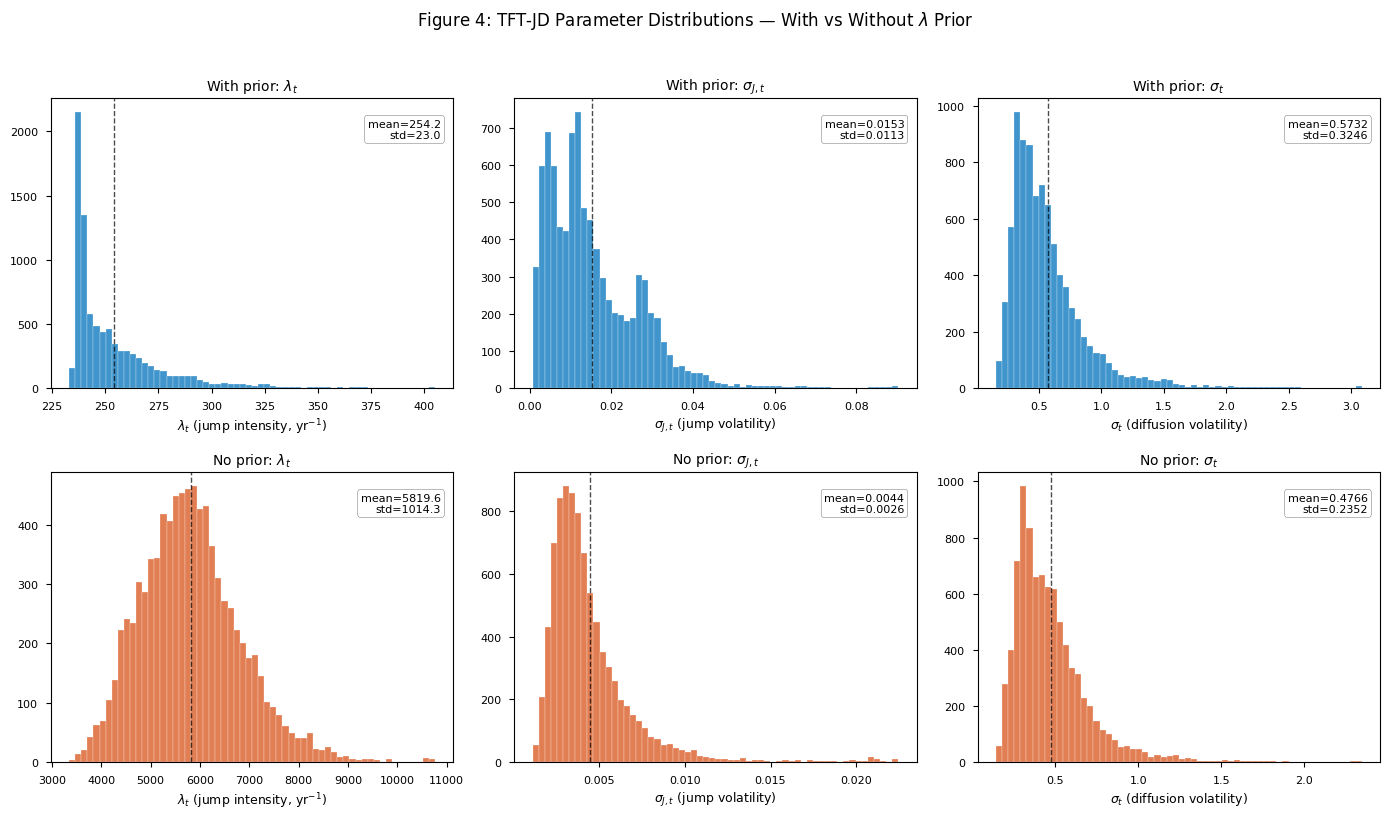

In [7]:
# ── §2.4: λ Prior Ablation — Static MLE & TFT Parameter Distributions ──
import yaml
cfg = yaml.safe_load(open(ROOT / "config.yaml"))
dt = 1.0 / cfg["training"]["bars_per_year"]

# --- Part A: Static MLE comparison (no bounds vs selected MAP) ---
# Stage 8b produces mle_unconstrained; run_full_pipeline.sh includes it
try:
    static_mle_unc = load_json("eth_static_jd_params_mle_unconstrained.json")
    has_mle_unc = True
except FileNotFoundError:
    has_mle_unc = False
eth_prod = load_json("eth_static_jd_params.json")

rows_prior = []
if has_mle_unc:
    rows_prior.append({"Setting": "Pure MLE (no prior, no bounds)",
     "λ (yr⁻¹)": f'{static_mle_unc["lambda"]:.0f}',
     "σ_J": f'{static_mle_unc["sigma_J"]:.4f}',
     "μ_J": f'{static_mle_unc["mu_J"]:.6f}',
     "Interpretation": "λ→∞, σ_J→0: jumps degenerate into diffusion"})
rows_prior.append({"Setting": "MAP with empirical prior (selected checkpoint)",
     "λ (yr⁻¹)": f'{eth_prod["lambda"]:.0f}',
     "σ_J": f'{eth_prod["sigma_J"]:.4f}',
     "μ_J": f'{eth_prod["mu_J"]:.5f}',
     "Interpretation": "Interpretable: ~4 jumps/week, meaningful amplitude"})
if not has_mle_unc:
    print("[Note] eth_static_jd_params_mle_unconstrained.json missing. Run: python scripts/run_stage8b_lambda_ablation.py")
# Table shown in markdown cell above; omit print to avoid raw |---| in export

# --- Part B: TFT-JD parameter distributions ---
# "With prior" = eth_tft_jd_w_finetune.ckpt (selected source checkpoint, used by Stage 6)
# "No prior"   = eth_tft_jd_lambda0.ckpt (stage8b ablation, lambda_prior_weight=0)
import torch, sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.models.tft_jd import build_tft_jd, infer_eth_theta

npz = np.load(ROOT / "data" / "features" / "ETH_tft_arrays.npz", allow_pickle=True)
X_hist, Z_future, y_arr, split = npz["X_hist"], npz["Z_future"], npz["y"], np.asarray(npz["split"])
valid = np.isfinite(y_arr)
X_hist, Z_future, y_arr, split = X_hist[valid], Z_future[valid], y_arr[valid], split[valid]
test_mask = split == "test"

tft_params = {}
for label, ckpt_name in [("With prior", "eth_tft_jd_w_finetune.ckpt"),
                           ("No prior", "eth_tft_jd_lambda0.ckpt")]:
    p = CKPT / ckpt_name
    if not p.exists():
        print(f"  {label}: checkpoint {ckpt_name} not found, skipping")
        continue
    model = build_tft_jd()
    ck = torch.load(p, map_location="cpu")
    model.load_state_dict(ck["model_state_dict"], strict=True)
    theta_list = infer_eth_theta(model, X_hist[test_mask], Z_future[test_mask],
                                  batch_size=2048, device="cpu")
    theta = np.array([[t["mu"], t["sigma"], t["lam"], t["mu_j"], t["sigma_j"]]
                       for t in theta_list], dtype=np.float64)
    tft_params[label] = theta
    # Omit raw console dump; values summarized in prose below

# --- Figure 4: 2×3 grid — separate panels so each is readable ---
params_info = [
    (2, "$\\lambda_t$ (jump intensity, yr$^{-1}$)", "$\\lambda_t$"),
    (4, "$\\sigma_{J,t}$ (jump volatility)", "$\\sigma_{J,t}$"),
    (1, "$\\sigma_t$ (diffusion volatility)", "$\\sigma_t$"),
]
labels_order = ["With prior", "No prior"]
labels_order = [l for l in labels_order if l in tft_params]
if len(labels_order) < 2:
    print("[Note] eth_tft_jd_lambda0.ckpt missing. Run: python scripts/run_stage8b_lambda_ablation.py")
colors_ab = {"With prior": "#0072BD", "No prior": "#D95319"}

nrows = len(labels_order) if labels_order else 1
fig, axes = plt.subplots(max(1, nrows), 3, figsize=(14, 4 * nrows), squeeze=False)
for col, (idx, xlabel, short) in enumerate(params_info):
    for row, label in enumerate(labels_order):
        ax = axes[row, col]
        theta = tft_params[label]
        vals = theta[:, idx]
        ax.hist(vals, bins=60, color=colors_ab[label], edgecolor="white",
                alpha=0.75)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_title(f"{label}: {short}", fontsize=10)
        # Add summary stats
        ax.axvline(vals.mean(), color="black", ls="--", lw=1, alpha=0.7)
        ax.text(0.97, 0.93, f"mean={vals.mean():.1f}\nstd={vals.std():.1f}" if idx == 2
                else f"mean={vals.mean():.4f}\nstd={vals.std():.4f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

fig.suptitle("Figure 4: TFT-JD Parameter Distributions — With vs Without $\\lambda$ Prior",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "report_fig4_lambda_prior_ablation.png", dpi=DPI, bbox_inches="tight")
plt.show()

Without any prior or parameter bounds, MLE drives λ to over 9000 yr⁻¹ while σ\_J collapses to 0.006 — the jump component degenerates into additional diffusion, with each "jump" contributing negligible amplitude. The MAP prior with empirical p\_center produces λ = 216 with σ\_J = 0.022, corresponding to roughly 4 jumps per week with meaningful size.

Figure 4 shows the same phenomenon in the TFT-JD neural setting. With the selected source checkpoint (prior + weakness fine-tuning), $\lambda_t$ has mean 254.2 (std 23.0), $\sigma_{J,t}$ mean 0.0153, and $\sigma_t$ mean 0.5732. Without the prior, the corresponding values shift to $\lambda_t$ mean 5819.6 (std 1014.3), $\sigma_{J,t}$ mean 0.0044, and $\sigma_t$ mean 0.4766 — consistent with a degenerate many-small-jumps regime. The weakness regularization helps break the $\lambda$–$\sigma_J$ coupling beyond what the prior alone achieves, since it penalizes degenerate parameterizations through the prospect-theory channel (§4).

**Empirical jump frequency estimation.** Rather than picking λ\_center by hand, we estimate it from data using two complementary detectors:

- **Barndorff-Nielsen & Shephard (BNS)** test: compares realized variance with bipower variation to detect days with significant jump activity. Applied to ETH training data (2022-01 – 2024-09), BNS flags 826 jump-days out of ~3.5 years, giving λ̂\_BNS ≈ 236 yr⁻¹.
- **Lee & Mykland** test: a bar-level jump detector using the ratio of absolute return to local bipower volatility. With a 5% significance threshold, it identifies 156 jumps, giving λ̂\_LM ≈ 45 yr⁻¹.

The two estimates bracket the true frequency: BNS is liberal (counts any day with excess variation), while Lee-Mykland is conservative (only flags extreme individual bars). We combine them with a threshold-based cross-check (|r| > kσ\_rolling for k ∈ {3, 4, 5}), yielding a recommended λ̂ ≈ 140 yr⁻¹.

**MAP prior formulation.** The prior is placed on the per-bar jump probability p = 1 − exp(−λΔt):

$$\log \pi(p) = -w_{\text{prior}} \cdot \bigl(\text{logit}(p) - \text{logit}(p_{\text{center}})\bigr)^2$$

where p\_center is derived from λ̂. This logit-normal form concentrates penalty near the center while allowing the optimizer freedom in the tails. The selected source checkpoint uses p\_center from the empirical pipeline, producing λ = 216 with σ\_J = 0.022 — a physically interpretable parameterization where jumps occur roughly 4 times per week with meaningful amplitude.

---

# 3. Source Model: JD Density & TFT Conditioning

## 3.1 Jump-Diffusion Density

The return process follows Merton's jump-diffusion (Eq. 1):
$$r_{t+1} = \mu_t \Delta t + \sigma_t \sqrt{\Delta t}\, \varepsilon_t + \sum_{k=1}^{N_t} Y_{t,k}$$
where $\varepsilon_t \sim \mathcal{N}(0,1)$, $N_t \sim \text{Poisson}(\lambda_t \Delta t)$, and $Y_{t,k} \sim \mathcal{N}(\mu_J, \sigma_J^2)$. All parameters are annualized; $\Delta t = 1/35040$ for 15-minute bars.

The log-density (Eq. 8) is a truncated Poisson mixture of Gaussians:
$$\log p(r \mid \theta) = \log \sum_{n=0}^{n_{\max}} \frac{(\lambda \Delta t)^n e^{-\lambda \Delta t}}{n!} \cdot \phi\!\left(r;\, \mu \Delta t + n \mu_J,\, \sigma^2 \Delta t + n \sigma_J^2\right)$$
We truncate at $n_{\max} = 10$ (from `config.yaml: jd_truncation_n`). The sum is computed in log-space via `logsumexp` to avoid numerical underflow — critical when $\lambda \Delta t$ is small and most Poisson terms are near zero.

**Static MAP estimation.** Before training the TFT, we fit a static 5-parameter JD model $\theta_{\text{static}} = (\mu, \sigma, \lambda, \mu_J, \sigma_J)$ to ETH training returns via MAP (§2.4). This serves two purposes: (i) as an integration test for the density implementation, and (ii) as the initialization anchor for TFT-JD parameter heads.

In [8]:
# ── Table 3: Static JD MAP Parameters (all assets) ──
assets = ["ETH", "BTC", "SOL", "DOGE"]
rows = []
for a in assets:
    try:
        p = load_json(f"{a}_static_jd_params.json")
    except FileNotFoundError:
        p = load_json(f"{a.lower()}_static_jd_params.json")
    rows.append({
        "Asset": a, "μ": f'{p["mu"]:.2f}', "σ": f'{p["sigma"]:.3f}',
        "λ (yr⁻¹)": f'{p["lambda"]:.0f}', "μ_J": f'{p["mu_J"]:.5f}', "σ_J": f'{p["sigma_J"]:.4f}',
    })
df_jd = pd.DataFrame(rows)
print(df_jd.to_markdown(index=False))

| Asset   |    μ |     σ |   λ (yr⁻¹) |      μ_J |    σ_J |
|:--------|-----:|------:|-----------:|---------:|-------:|
| ETH     | 0.6  | 0.453 |        216 | -0.00072 | 0.0224 |
| BTC     | 0.6  | 0.371 |        202 | -0.00052 | 0.02   |
| SOL     | 0.32 | 0.834 |        159 |  0       | 0.0425 |
| DOGE    | 0.21 | 0.649 |        207 | -0.00036 | 0.0324 |


**Table 3.** Static JD MAP parameters (annualized). SOL has the highest $\sigma$ (0.834) and lowest $\lambda$ (159), consistent with its more volatile, less jump-dominated dynamics. BTC and ETH are similar in structure, supporting the transfer feasibility between them. Most $\mu_J$ values are slightly negative, reflecting the asymmetry of crypto jumps; SOL is approximately zero.

## 3.2 TFT-JD Architecture

The Temporal Fusion Transformer encoder (Eq. 2–6) maps historical features and time covariates to a hidden representation, from which five independent parameter heads produce time-varying JD parameters:

<table>
<colgroup><col style="width:12%"><col style="width:12%"><col style="width:38%"><col style="width:38%"></colgroup>
<thead><tr><th>Head</th><th>Output</th><th>Constraint</th><th>Activation</th></tr></thead>
<tbody>
<tr><td>$f_\mu$</td><td>$\mu_t$</td><td>Unconstrained</td><td>Linear</td></tr>
<tr><td>$f_\sigma$</td><td>$\sigma_t$</td><td>$>0$</td><td>Softplus + $\epsilon$</td></tr>
<tr><td>$f_\lambda$</td><td>$\lambda_t$</td><td>$>0$, bounded</td><td>Softplus + $\epsilon$, clamp $\le\lambda_{\max}$</td></tr>
<tr><td>$f_{\mu_J}$</td><td>$\mu_{J,t}$</td><td>$\in[-0.06,0.06]$</td><td>Tanh$\times$scale</td></tr>
<tr><td>$f_{\sigma_J}$</td><td>$\sigma_{J,t}$</td><td>$>0$</td><td>Softplus + $\epsilon$</td></tr>
</tbody></table>

Each head is a small MLP (Linear → ReLU → Linear). The output biases are initialized from the static MAP parameters (Table 3), so the TFT starts near a known-good solution and learns time-varying deviations. Weight initialization uses small random values ($\text{std} = 10^{-3}$) to ensure the initial output is close to the bias.

**Architecture hyperparameters:** hidden size = 64, attention heads = 4, dropout = 0.15, $\epsilon = 10^{-4}$. Input shape: $X_{\text{hist}} \in \mathbb{R}^{B \times 96 \times 14}$, $Z_{\text{future}} \in \mathbb{R}^{B \times 1 \times 4}$.

## 3.3 Training Loss

The combined loss follows Eq. (7):
$$L(\theta, r) = \text{NLL}(\theta, r) + \alpha \cdot \text{CRPS}(\theta, r) + \beta \cdot R(\theta)$$

- **NLL**: $-\sum_t \log p(r_t \mid \theta_t)$ using the JD density (Eq. 8)
- **CRPS**: Continuous Ranked Probability Score, estimated via Monte Carlo sampling ($M = 200$ draws from $p(r \mid \theta)$). The JD mixture has no closed-form CRPS, so MC approximation is necessary.
- **$R(\theta)$**: A soft $\lambda$-prior regularizer (`lambda_prior_weight` $= 0.05$) that penalizes deviation of $\lambda_t$ from the static MAP center, extending the §2.4 prior into the neural setting.

Training uses Adam with `lr = 3e-4`, weight decay $10^{-3}$, gradient clipping at 1.0, batch size 128, and early stopping on validation NLL with patience 15. Three training modes are used:
- **Base**: NLL + CRPS only (produces `eth_tft_jd.ckpt`)
- **Scratch+W**: NLL + CRPS + weakness regularization from random init (produces `eth_tft_jd_w_scratch.ckpt`)
- **Finetune+W**: NLL + CRPS + weakness, initialized from base checkpoint (produces `eth_tft_jd_w_finetune.ckpt`)

## 3.4 Ablation Discussion

Returning to Table 1, the progressive improvement tells a clear story:

**GBM → Static-JD (ΔNLL = −0.04).** Adding the jump component provides a modest but consistent improvement. The static JD captures heavy tails better than a Gaussian, but with fixed parameters it cannot adapt to changing market conditions — hence the limited gain.

**Static-JD → TFT-JD (ΔNLL = −0.19).** This is the largest single improvement. Time-varying parameters allow the model to increase $\sigma_t$ during volatile periods and adjust $\lambda_t$ when jump activity changes. The 5× larger gain over the static jump component confirms that **parameterization dynamics matter more than the jump specification itself**.

**TFT-JD → TFT-JD+W (ΔNLL = +0.03).** Weakness regularization slightly hurts raw likelihood — it diverts some model capacity toward behavioral calibration. However, this tradeoff is by design: the weakness term (§4) encourages the model to produce parameters that are "robust" in a prospect-theoretic sense, which becomes valuable during transfer learning (§6).

**PIT calibration.** The TFT-JD achieves the best PIT KS statistic (0.017), but with $n = 8{,}736$ test samples even this small deviation produces $p = 0.012$ (p-value computed via `scipy.stats.kstest` using the asymptotic Kolmogorov distribution), formally rejecting uniformity. This is a known property of the KS test at large sample sizes — the actual calibration departure is negligible for practical purposes.

---

# 4. Behavioral Weakness Regularization

## 4.1 $W_{PT}$ Implementation

Our implementation of $W_{PT}$ (Eq. 37) follows an 8-step computation in `src/behavioral/weakness.py::compute_w_pt`:

<table>
<colgroup><col style="width:8%"><col style="width:18%"><col style="width:74%"></colgroup>
<thead><tr><th>Step</th><th>Operation</th><th>Code</th></tr></thead>
<tbody>
<tr><td>1</td><td>Jump probability</td><td>$p_\mathrm{jump} = 1 - \exp(-\lambda_t \cdot \Delta t)$, clamped to [1e-10, 1]</td></tr>
<tr><td>2</td><td>Prelec weighting</td><td>$\pi_\mathrm{val} = \exp(-(-\ln p_\mathrm{jump})^\delta)$ with $\delta = 0.69$</td></tr>
<tr><td>3</td><td>Prospect value</td><td>$m = \mu_t - \lambda_t \cdot \mu_{J,t}$; $v_\mathrm{val} = m^\alpha$ (gain) or $-\lambda_\mathrm{loss}(-m)^\beta$ (loss)</td></tr>
<tr><td>4–5</td><td>Tail risk</td><td>CVaR at $\alpha=5\%$ under JD density; $\mathrm{risk\_factor} = \exp(-\gamma \cdot \mathrm{CVaR}_\mathrm{loss})$ with $\gamma=7.0$</td></tr>
<tr><td>6</td><td>Raw score</td><td>$\mathrm{raw} = \pi_\mathrm{val} \times v_\mathrm{val} \times \mathrm{risk\_factor}$</td></tr>
<tr><td>7</td><td>Activation</td><td>$w_\mathrm{pt\_raw} = \mathrm{softplus}(\mathrm{raw})$</td></tr>
<tr><td>8</td><td>Normalization</td><td>$w_\mathrm{pt} = w_\mathrm{pt\_raw} / \max(w_\mathrm{pt\_raw}).\mathrm{detach}()$, clamped to [1e-8, 1]</td></tr>
</tbody></table>

Step 8 uses **batch-max normalization**: dividing by the maximum raw score within the current batch (detached from the gradient graph). This keeps $W_{PT} \in (0, 1]$ and ensures the $-\log W_{PT}$ loss term stays bounded. In Phase 3 (§6.3), source and target samples are normalized jointly within the same batch — this is critical for cross-asset comparability.

**CVaR computation** uses two modes: an analytic heuristic (fast, differentiable, used during training) and Monte Carlo sampling with 5000 draws (used during validation for accuracy). The analytic version approximates the JD mixture's left tail using the dominant Gaussian component weighted by Poisson probabilities — accurate when λΔt is small.

## 4.2 Weakness Loss Design

The weakness loss $L_{\text{weakness}}$ plays different roles in the two TransWeave training phases:

**Phase 3** (joint training, §6.3) uses the full formula (Eq. 50):

$$L_{\text{weakness}} = -\log W_{PT} + \text{MSE}(W_{PT}^{\text{pred}},\, W_{PT}^{\text{target}})$$

The first term encourages behavioral robustness; the second aligns the transfer map's output weakness profile with the weak target model. Phase 3 weight: $\lambda_{wpt} = 0.1$.

**Phase 4** (fine-tuning, §6.4) uses only the log term, following Algorithm 1's gradient form $\nabla L = \nabla L_{\text{data}} - \beta \nabla \log W_{PT}$:

$$L_{\text{weakness}}^{(\text{P4})} = -\log W_{PT}$$

Phase 4 weight: $\lambda_{wpt} = 1.0$ (higher than Phase 3, since this is now the only regularization signal besides the L2 anchor).

## 4.3 Effect on λ Parameter Dynamics

An unexpected benefit of weakness regularization is its interaction with the λ–σ\_J degeneracy (§2.4). We compare three ETH TFT-JD training modes on the same architecture:

| Training mode | λ mean | λ std | σ\_J mean | Note |
|---|---|---|---|---|
| Base (prior only) | 219 | 0.5 | 0.0042 | λ locked near MAP center, σ\_J collapsed |
| **W-finetune** (prior + weakness) | 254 | 23.0 | 0.0153 | λ freed, σ\_J interpretable |
| W-scratch (weakness, no base init) | 3334 | 75.7 | 0.0370 | λ degenerates despite weakness* |

*W-scratch includes the λ prior (weight=0.05) but the weakness gradient overwhelms it, pulling λ to a degenerate basin before the prior can anchor it.*

The base model with prior alone locks λ near 219 with negligible variation — the prior prevents degeneration but also suppresses time-varying signal. The **weakness-finetuned** model (initialized from the base checkpoint, then fine-tuned with weakness loss) breaks this stasis: λ\_t acquires meaningful temporal variation (std = 23) while staying in a physically reasonable range, and σ\_J increases 3.6× to 0.015.

The mechanism: the weakness loss penalizes parameterizations where π(p\_jump) · v(m) produces extreme values. Degenerate "many tiny jumps" configurations have high p\_jump (pushing π toward 1) but trivial v(m) (near-zero drift adjustment), creating a gradient that pushes the model away from the degenerate region. This only works when starting from a well-initialized base — training from scratch with weakness (W-scratch) cannot find the right basin and degenerates to λ ≈ 3300.

The selected source checkpoint used for all transfer experiments in §6 is the W-finetune variant.

---

# 5. Regime Detection & Transfer Feasibility

Before running the transfer learning pipeline, we assess whether transfer from ETH to each target is feasible. This follows the paper's two-phase decision process (Algorithm 1, Phases 1–2): first check whether the source and target are in the "same domain" (Phase 1), then determine the transfer mode — Full, Partial, or Weak (Phase 2).

## 5.1 HMM Regime Detection

We fit a 4-state Gaussian HMM to each asset's feature space to identify market regimes. The number of states is fixed at 4 (not selected via BIC) because the transfer metrics (Eq. 13, 22) require consistent dimensionality across assets.

**Feature preparation:** The 14 TFT features are downsampled from 15-minute to 1-hour resolution (factor 4), then columns with >50% missing values are dropped. PCA is applied to the remaining features, retaining components explaining ≥85% variance (up to 6 components). This produces a compact, comparable feature space across all four assets.

**HMM fitting:** Each asset's PCA features are fitted independently with `GaussianHMM(n_components=4, covariance_type="full")`, using 5 random initializations and selecting the best by log-likelihood. The resulting state sequences, transition matrices P, and eigenvector decompositions V are saved for the transfer metrics.

## 5.2 $W_{\text{crit}}$ and Phase 1 (Go/No-Go)

Phase 1 checks whether the JD parameter distributions of source and target are close enough to justify transfer. The Wasserstein distance between rolling-window JD parameter distributions (Eq. 12) is compared against a critical threshold:

$$W_{\text{crit}} = 2 \sqrt{(\bar{\sigma}^2 + \bar{\lambda})}$$

where $\bar{\sigma}$ and $\bar{\lambda}$ are rolling-window means over aligned source and target $\theta$ sequences. With 30-day non-overlapping windows (2880 bars each, 33 windows total), we compute the p90 of per-window $W_{JD}$ values and check $W_{JD} / W_{\text{crit}}$. $W_{\text{crit}}$ is computed per pair; the resulting values are numerically very similar across the three crypto targets (~23.8), reflecting the similar parameter scales of the four assets.

**Table 4.** Transfer feasibility metrics (single-line format for PDF export):

| Target | $W_{JD}$ (p90) | $W_{\text{crit}}$ | $W_{JD}/W_{\text{crit}}$ | Phase 1 | $\rho_{\text{regime}}$ | $\Delta W_{PT}$ (p90) | $S_{\text{transfer}}$ | Decision |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **BTC** | 2.247 | 23.8 | 0.094 | Pass | 0.768 | 0.0409 | 0.570 | Full |
| **SOL** | 4.721 | 23.8 | 0.198 | Pass | 0.714 | 0.0810 | 0.391 | Partial |
| **DOGE** | 3.918 | 23.8 | 0.165 | Pass | 0.662 | 0.0490 | 0.440 | Partial |

In [9]:
# ── Table 4: Transfer Feasibility Metrics ──
s5_by = {p["target"]: p for p in s5["pairs"]}

rows = []
for t in ["BTC", "SOL", "DOGE"]:
    p = s5_by[t]
    rows.append({
        "Target": t,
        "W_JD (p90)": f'{p["w_jd_effective"]:.3f}',
        "W_crit": f'{p["w_crit"]:.1f}',
        "W_JD/W_crit": f'{p["w_jd_over_w_crit"]:.3f}',
        "Phase 1": "Pass" if p["w_jd_over_w_crit"] < 1.0 else "Reject",
        "ρ_regime": f'{p["rho"]:.3f}',
        "ΔW_PT (p90)": f'{p["delta_wpt_p90"]:.4f}',
        "S_transfer": f'{p["s_transfer"]:.3f}',
        "Decision": p["decision"].capitalize(),
    })
# Table shown in markdown cell above; omit print to avoid raw |---| in PDF export

**Table 4.** Transfer feasibility metrics. W\_JD/W\_crit < 1 passes Phase 1 (same-domain check). All three targets pass comfortably — W\_JD/W\_crit ranges from 0.094 (BTC) to 0.198 (SOL), far below the rejection threshold. This is perhaps unsurprising: all four assets are cryptocurrencies sharing the same macro environment, so their JD parameter distributions overlap substantially. The Phase 1 check would be more discriminating for cross-asset-class transfer (e.g., crypto → equities).

## 5.3 $\rho_{\text{regime}}$: Regime Overlap

The regime overlap coefficient $\rho_{\text{regime}}$ (Eq. 13) measures how well the HMM eigenvectors of the source align with those of the target:

$$\rho_{\text{regime}} = \max_\pi \sum_{i,j} \pi_{ij} \langle v_i^{(a)}, v_j^{(b)} \rangle$$

where the maximization is over permutation matrices π (accounting for arbitrary state labeling). Following the paper, we exclude the stationary eigenvector (eigenvalue λ = 1) from the computation, focusing on the *dynamic* regime structure rather than the equilibrium distribution.

Results: BTC (ρ = 0.768) > SOL (ρ = 0.714) > DOGE (ρ = 0.662). This ordering matches intuition — BTC shares the most market-structure similarity with ETH, while DOGE's meme-driven dynamics produce the most distinct regime transitions.

## 5.4 S\_transfer: Composite Feasibility Score

The composite transfer score (Eq. 58) combines all three signals:

$$S_{\text{transfer}} = \exp(-W_{JD}/W_{\text{crit}}) \cdot \rho \cdot \exp(-|\Delta W_{PT}| / 0.2)$$

This multiplicative form means each factor can independently suppress the score: high W\_JD (parameter distance), low ρ (regime mismatch), or large ΔW\_PT (behavioral divergence) all reduce S. The results — BTC (0.570) > DOGE (0.440) > SOL (0.391) — match the observed ranking in this three-target experiment (Table 2).

## 5.5 Decision Matrix

The paper's Theorem 5.1 specifies three necessary conditions for transfer success: (i) W\_JD < W\_crit (statistical compatibility), (ii) ρ\_regime > 0.5 (structure alignment), and (iii) ΔW\_PT / (W\_PT^a + W\_PT^b) < 0.2 (behavioral consistency). Phase 2 refines these into a transfer mode assignment:

| Condition | Decision |
|---|---|
| ρ ≥ 0.7 and ΔW\_PT < δ\_full and S ≥ 0.5 | **Full** |
| ρ ≥ 0.7 and ΔW\_PT < δ\_full but S < 0.5 | **Partial** (downgrade) |
| 0.5 ≤ ρ < 0.7 | **Partial** |
| 0.3 ≤ ρ < 0.5 | **Weak** |
| ρ < 0.3 or W\_JD > W\_crit | **Reject** |

Our implementation uses $\delta_{\text{full}} = 0.1$ (stricter than the paper's theoretical bound of 0.2). When ρ and ΔW\_PT both pass the Full thresholds but S\_transfer < 0.5, the decision is downgraded to Partial — this follows Section 6.1 of the paper, which recommends S > 0.5 for full transfer.

**BTC** (ρ = 0.768, ΔW\_PT = 0.041, S = 0.570): passes all Full thresholds → **Full transfer**. The transfer map operates with the highest λ\_TW weight (0.1), giving maximum intertwining regularization.

**SOL** (ρ = 0.714, ΔW\_PT = 0.081, S = 0.391): ρ passes the Full threshold (0.714 > 0.7) and ΔW\_PT < 0.1, but S = 0.391 falls below 0.5, triggering a **downgrade to Partial**. This is the most instructive case: ρ alone would suggest Full transfer, but the lower S — driven by SOL's higher W\_JD (0.198 vs BTC's 0.094) and larger behavioral divergence — correctly identifies SOL as a harder target. The Partial mode uses a more conservative learning rate (1e-5 vs 5e-5) and tighter gradient clipping (0.1 vs 1.0).

**DOGE** (ρ = 0.662, S = 0.440): ρ falls in the Partial range (0.5 < 0.662 < 0.7) → **Partial transfer** directly. Despite being the "hardest" target by ρ, DOGE ends up with a higher S\_transfer than SOL (0.440 vs 0.391), and indeed outperforms SOL in the final transfer results (§1.2).

---

# 6. TransWeave Transfer Learning

This section details the core contribution: learning a parameter-space transfer map $T(\theta^{(a)}, \text{regime}) \to \theta^{(b)}$ that adapts the ETH source model's JD parameters to each target asset. Training proceeds in two phases: Phase 3 (joint learning of T with a weak target model) and Phase 4 (fine-tuning T on target returns with weakness regularization).

## 6.1 Architecture

**Transfer map T.** A regime-conditioned 3-layer MLP:

$$\begin{aligned} \text{Input: } & [\theta^{(a)} \in \mathbb{R}^5 \;\|\; \text{regime}_{\text{onehot}} \in \mathbb{R}^4] \\ & \downarrow \;\; \text{Linear}(9, 64) \to \text{ReLU} \\ & \downarrow \;\; \text{Linear}(64, 64) \to \text{ReLU} \\ & \downarrow \;\; \text{Linear}(64, 5) \to \text{residual}+\text{constraints} \to \theta^{(b)} \in \mathbb{R}^5 \end{aligned}$$


The map uses a **residual parameterization** in normalized space: input θ^(a) is z-scored using training-set statistics, the MLP predicts a small delta (scaled by 0.3), and the output is denormalized to target-asset parameter space. This ensures the map starts near identity and learns deviations. Output constraints: σ, λ, σ\_J are passed through softplus to guarantee positivity; μ and μ\_J are unconstrained.

**Weak target model (SimpleJDModel).** A single-layer linear model (14 features → 5 JD parameters) trained on each target asset with MAP prior (`prior_weight = 0.1`). This produces a baseline θ^(b) sequence that anchors Phase 3 training — without it, the transfer map has no signal about what target-asset parameters should look like.

## 6.2 Phase 3: Joint Training

Phase 3 learns the transfer map T by jointly minimizing three loss terms (Eq. 47):

$$L_{\text{unified}} = L_{JD} + \lambda_{TW} \cdot L_{\text{TransWeave}} + \lambda_{wpt} \cdot L_{\text{weakness}}$$

**L\_JD** (primary): NLL + CRPS of the mapped parameters against target returns.
$$L_{JD} = \text{NLL}_{\text{clamped}}(r^{(b)},\, T(\theta^{(a)})) + \alpha \cdot \text{CRPS}(T(\theta^{(a)}),\, r^{(b)})$$
NLL is clamped at mean ± 5σ per batch to prevent extreme bars from dominating gradients. α = 1.0.

**L\_TransWeave** (structure, Eq. 49): MSE between mapped parameters and weak-model parameters, normalized per-parameter to prevent λ (scale ~200) from dominating σ\_J (scale ~0.02). Includes an entropy-isometry term (λ\_ent = 0.01) that penalizes output distance collapse.

**L\_weakness** (behavioral, Eq. 50): $-\log W_{PT}(T(\theta^{(a)})) + \text{MSE}(W_{PT}^{\text{pred}}, W_{PT}^{\text{target}})$. Source and target W\_PT values are jointly normalized within each batch for cross-asset comparability.

Phase 3 hyperparameters: lr = 1e-3, batch\_size = 2048, patience = 10 on val\_unified.

## 6.3 Full vs Partial vs Weak Modes

The three transfer modes share the same architecture and loss formulas — they differ **only in the λ\_TW weight** and Phase 4 learning rate:

| Hyperparameter | Full | Partial | Weak |
|---|---|---|---|
| λ\_TW (Phase 3) | 0.10 | 0.05 | 0.025 |
| Phase 4 lr | 5e-5 | 1e-5 | 5e-5 |
| Phase 4 grad clip | 1.0 | 0.1 | 1.0 |
| λ\_wpt (Phase 3) | 0.1 | 0.1 | 0.1 |
| λ\_wpt (Phase 4) | 1.0 | 1.0 | 1.0 |

Full mode uses a higher λ\_TW, pulling $T(\theta^{(a)})$ closer to the weak model's $\theta^{(b)}$. Partial mode gives T more freedom to deviate and uses a more conservative Phase 4 learning rate (1e-5) with tighter gradient clipping (0.1).

## 6.4 Phase 4: Fine-tuning

Phase 4 fine-tunes the transfer map on target data, dropping $L_{\text{TransWeave}}$ and simplifying $L_{\text{weakness}}$:

$$L_{\text{Phase 4}} = L_{JD} + \lambda_{wpt} \cdot (-\log W_{PT}) + \mu \cdot \|T - T_{\text{Phase 3}}\|^2$$

Three changes from Phase 3: (1) no BD intertwining constraint — the map is free to adapt beyond the weak model's guidance; (2) $L_{\text{weakness}}$ reduces to just $-\log W_{PT}$ (the MSE consistency term is dropped since Phase 3 already aligned the profiles); (3) an **L2 anchor** (μ = 50.0) prevents the map from drifting too far from the Phase 3 solution. Note: the L2 anchor is our implementation choice, not prescribed in the paper — we found it necessary to stabilize $\text{Phase } 4$ training, as without it the map can overfit to noisy target returns.

**Phase 3/4 interaction lesson.** An early implementation used $\lambda_{wpt} = 0.5$ in Phase 3, which pushed $W_{PT}$ to a sharp minimum. Phase 4 then had no room to improve — val\_phase4 never beat the Phase 3 baseline. Reducing Phase 3 $\lambda_{wpt}$ to 0.1 flattens the $W_{PT}$ landscape and allows Phase 4 to make meaningful updates. This is visible in the training curves below.

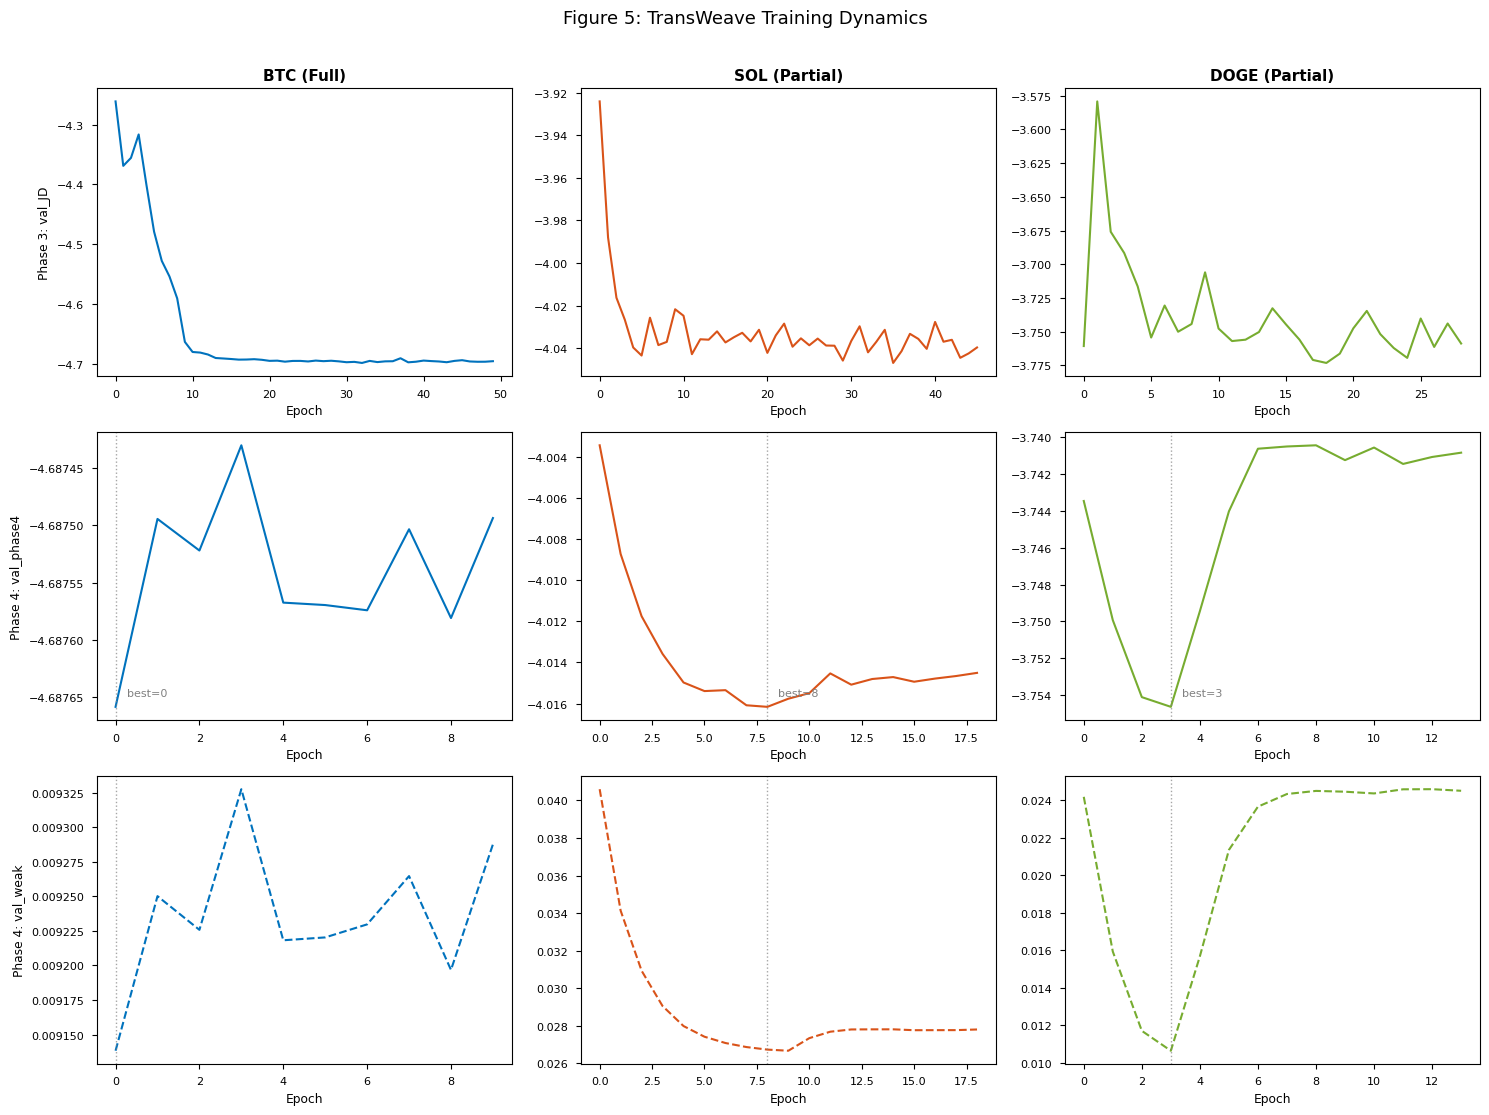

In [10]:
# ── Figure 5: Phase 3 & Phase 4 Training Curves (3×3 grid) ──
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
target_colors = {"BTC": "#0072BD", "SOL": "#D95319", "DOGE": "#77AC30"}

for col, r in enumerate(s6):
    t = r["target_asset"]
    c = target_colors[t]
    
    # Row 0: Phase 3 val_JD
    p3 = r["phase3_history"]
    epochs_p3 = [e["epoch"] for e in p3]
    val_jd_p3 = [e["val_JD"] for e in p3]
    ax = axes[0, col]
    ax.plot(epochs_p3, val_jd_p3, color=c, lw=1.5)
    ax.set_title(f"{t} ({r['decision'].capitalize()})", fontsize=11, fontweight="bold")
    ax.set_ylabel("Phase 3: val_JD" if col == 0 else "")
    ax.set_xlabel("Epoch")
    ax.ticklabel_format(useOffset=False)
    
    # Row 1: Phase 4 val_phase4
    p4 = r["phase4_history"]
    epochs_p4 = [e["epoch"] for e in p4]
    val_p4 = [e["val_phase4"] for e in p4]
    ax = axes[1, col]
    ax.plot(epochs_p4, val_p4, color=c, lw=1.5)
    conv = r["transweave"]["convergence_epoch"]
    ax.axvline(conv, color="gray", ls=":", lw=1, alpha=0.7)
    ax.annotate(f"best={conv}", xy=(conv, val_p4[min(conv, len(val_p4)-1)]),
                xytext=(8, 8), textcoords="offset points", fontsize=8, color="gray")
    ax.set_ylabel("Phase 4: val_phase4" if col == 0 else "")
    ax.set_xlabel("Epoch")
    ax.ticklabel_format(useOffset=False)
    
    # Row 2: Phase 4 val_weak
    val_weak_p4 = [e["val_weak"] for e in p4]
    ax = axes[2, col]
    ax.plot(epochs_p4, val_weak_p4, color=c, lw=1.5, ls="--")
    ax.axvline(conv, color="gray", ls=":", lw=1, alpha=0.7)
    ax.set_ylabel("Phase 4: val_weak" if col == 0 else "")
    ax.set_xlabel("Epoch")
    ax.ticklabel_format(useOffset=False)

fig.suptitle("Figure 5: TransWeave Training Dynamics", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "report_fig5_training_curves.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 6.5 Per-Target Analysis

**BTC (Full mode).** Phase 3 runs all 50 epochs with steady val\_JD improvement (−4.26 → −4.70). The L\_TransWeave term drops from ~1000 to ~1.0 over the first 10 epochs as the map learns the parameter-space alignment. Phase 4 converges immediately (best epoch = 0) — the Phase 3 solution is already near-optimal for BTC, and the L2 anchor prevents meaningful drift. Final test NLL: −4.860 (vs Scratch −4.788, Δ = −0.072). BTC is the clearest transfer success.

**SOL (Partial mode).** Phase 3 converges in 46 epochs. Phase 4 shows gradual improvement over 8 epochs (val\_phase4: −4.003 → −4.016), with val\_weak dropping from 0.041 to 0.027 (−34%) — the weakness regularization is actively reshaping the output distribution. Despite this improvement, the final test NLL (−4.142) slightly underperforms Scratch (−4.177, Δ = +0.035). SOL's distinct volatility regime — σ = 0.834 annualized, nearly 2× ETH's — limits how much the ETH-anchored transfer map can help.

**DOGE (Partial mode).** Phase 3 converges early (29 epochs). Phase 4 best at epoch 3 — the map improves briefly then the L2 anchor pulls it back. Final test NLL: −4.084 (vs Scratch −4.038, Δ = −0.046). DOGE is the most surprising success: despite the lowest $\rho_{\text{regime}}$ (0.662), TransWeave matches the fully-trained Target-TFT (−4.083 vs −4.084). This suggests the transfer map captures useful cross-asset structure even for meme-driven assets.

## 6.6 Direct Transfer Baseline

"Direct" applies the source ETH TFT-JD parameters to target returns without any adaptation — effectively $T = \text{identity}$. It consistently underperforms all other methods (BTC: −4.746, SOL: −4.041, DOGE: −3.850), confirming that naive parameter sharing fails. The gap between Direct and TransWeave (BTC: −0.114, SOL: −0.101, DOGE: −0.234) quantifies the value of the learned mapping.

## 6.7 Implementation Note: Parameter-Space vs State-Space

The paper's theoretical framework (Section 3) formulates TransWeave using Bellman–Darboux intertwining operators that act on the state-space dynamics. Our implementation simplifies this to a **parameter-space regression**: $T(\theta^{(a)}_t, \text{regime}_t) \to \theta^{(b)}_t$. This means the transfer map sees only the source JD parameters and regime label at each timestep — it does not condition on target-asset features $X^{(b)}_t$.

This is a deliberate simplification. The parameter-space formulation is tractable (the map has only 9 input dimensions), avoids the need for paired source-target feature windows, and still achieves meaningful transfer gains. However, it may limit performance on targets where the source features are uninformative about target dynamics — which may partly explain SOL's underperformance.

---

# 7. Parameter Dynamics & Diagnostics

## 7.1 Time-Varying Parameters

The TFT-JD source model produces per-bar JD parameters that should respond to market conditions. We examine the selected source checkpoint's (`eth_tft_jd_w_finetune.ckpt`) five output parameters on the ETH test set, followed by the TransWeave-mapped parameters for each target asset.

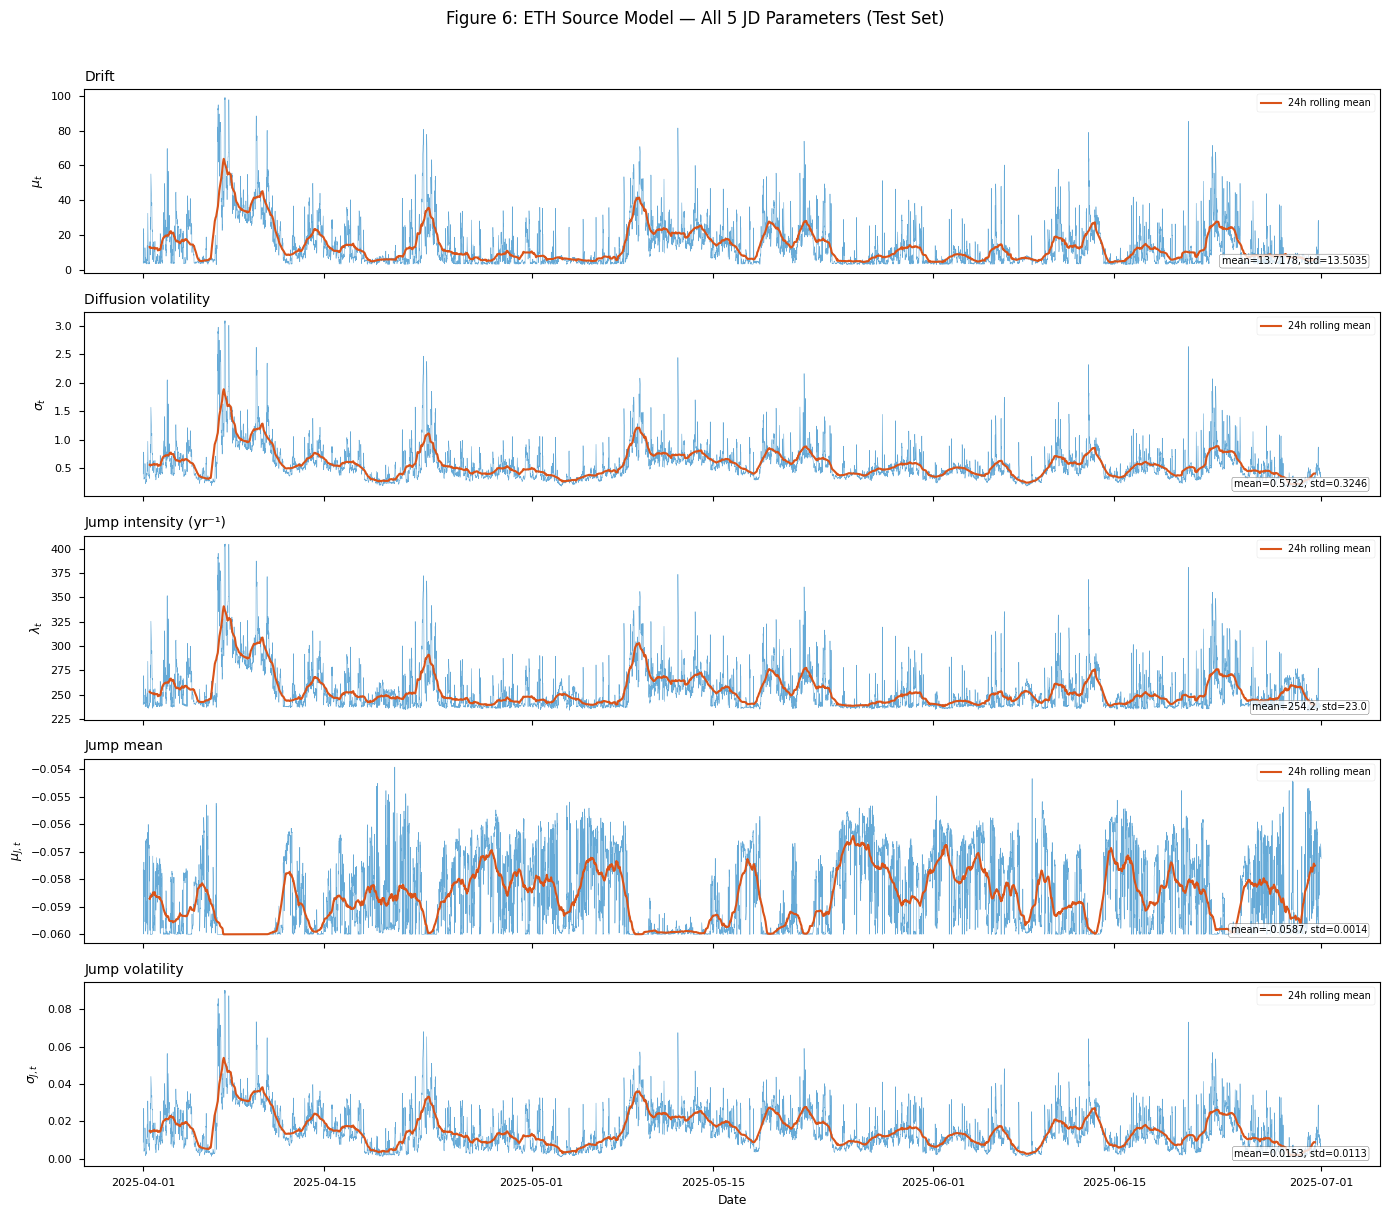

In [11]:
# ── Figure 6: ETH TFT-JD Parameter Time Series (all 5 params) ──
# Reuse tft_params from §2.4 cell (cell-19)
theta_wp = tft_params["With prior"]  # (n_test, 5): mu, sigma, lam, mu_j, sigma_j

test_start = pd.Timestamp("2025-04-01")
test_idx = pd.date_range(test_start, periods=len(theta_wp), freq="15min")

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
param_info = [
    (0, "$\\mu_t$", "Drift"),
    (1, "$\\sigma_t$", "Diffusion volatility"),
    (2, "$\\lambda_t$", "Jump intensity (yr⁻¹)"),
    (3, "$\\mu_{J,t}$", "Jump mean"),
    (4, "$\\sigma_{J,t}$", "Jump volatility"),
]
window = 96  # 24h rolling
for ax, (idx, label, title) in zip(axes, param_info):
    vals = theta_wp[:, idx]
    ax.plot(test_idx, vals, lw=0.4, alpha=0.6, color="#0072BD")
    if len(vals) > window:
        rolling = pd.Series(vals).rolling(window, center=True).mean()
        ax.plot(test_idx, rolling, lw=1.5, color="#D95319", label="24h rolling mean")
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(title, fontsize=10, loc="left")
    ax.legend(fontsize=7, loc="upper right")
    stats = f"mean={vals.mean():.4f}, std={vals.std():.4f}" if idx != 2 else f"mean={vals.mean():.1f}, std={vals.std():.1f}"
    ax.text(0.99, 0.05, stats, transform=ax.transAxes, ha="right", fontsize=7,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))

axes[-1].set_xlabel("Date")
fig.suptitle("Figure 6: ETH Source Model — All 5 JD Parameters (Test Set)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "report_fig6_eth_params.png", dpi=DPI, bbox_inches="tight")
plt.show()

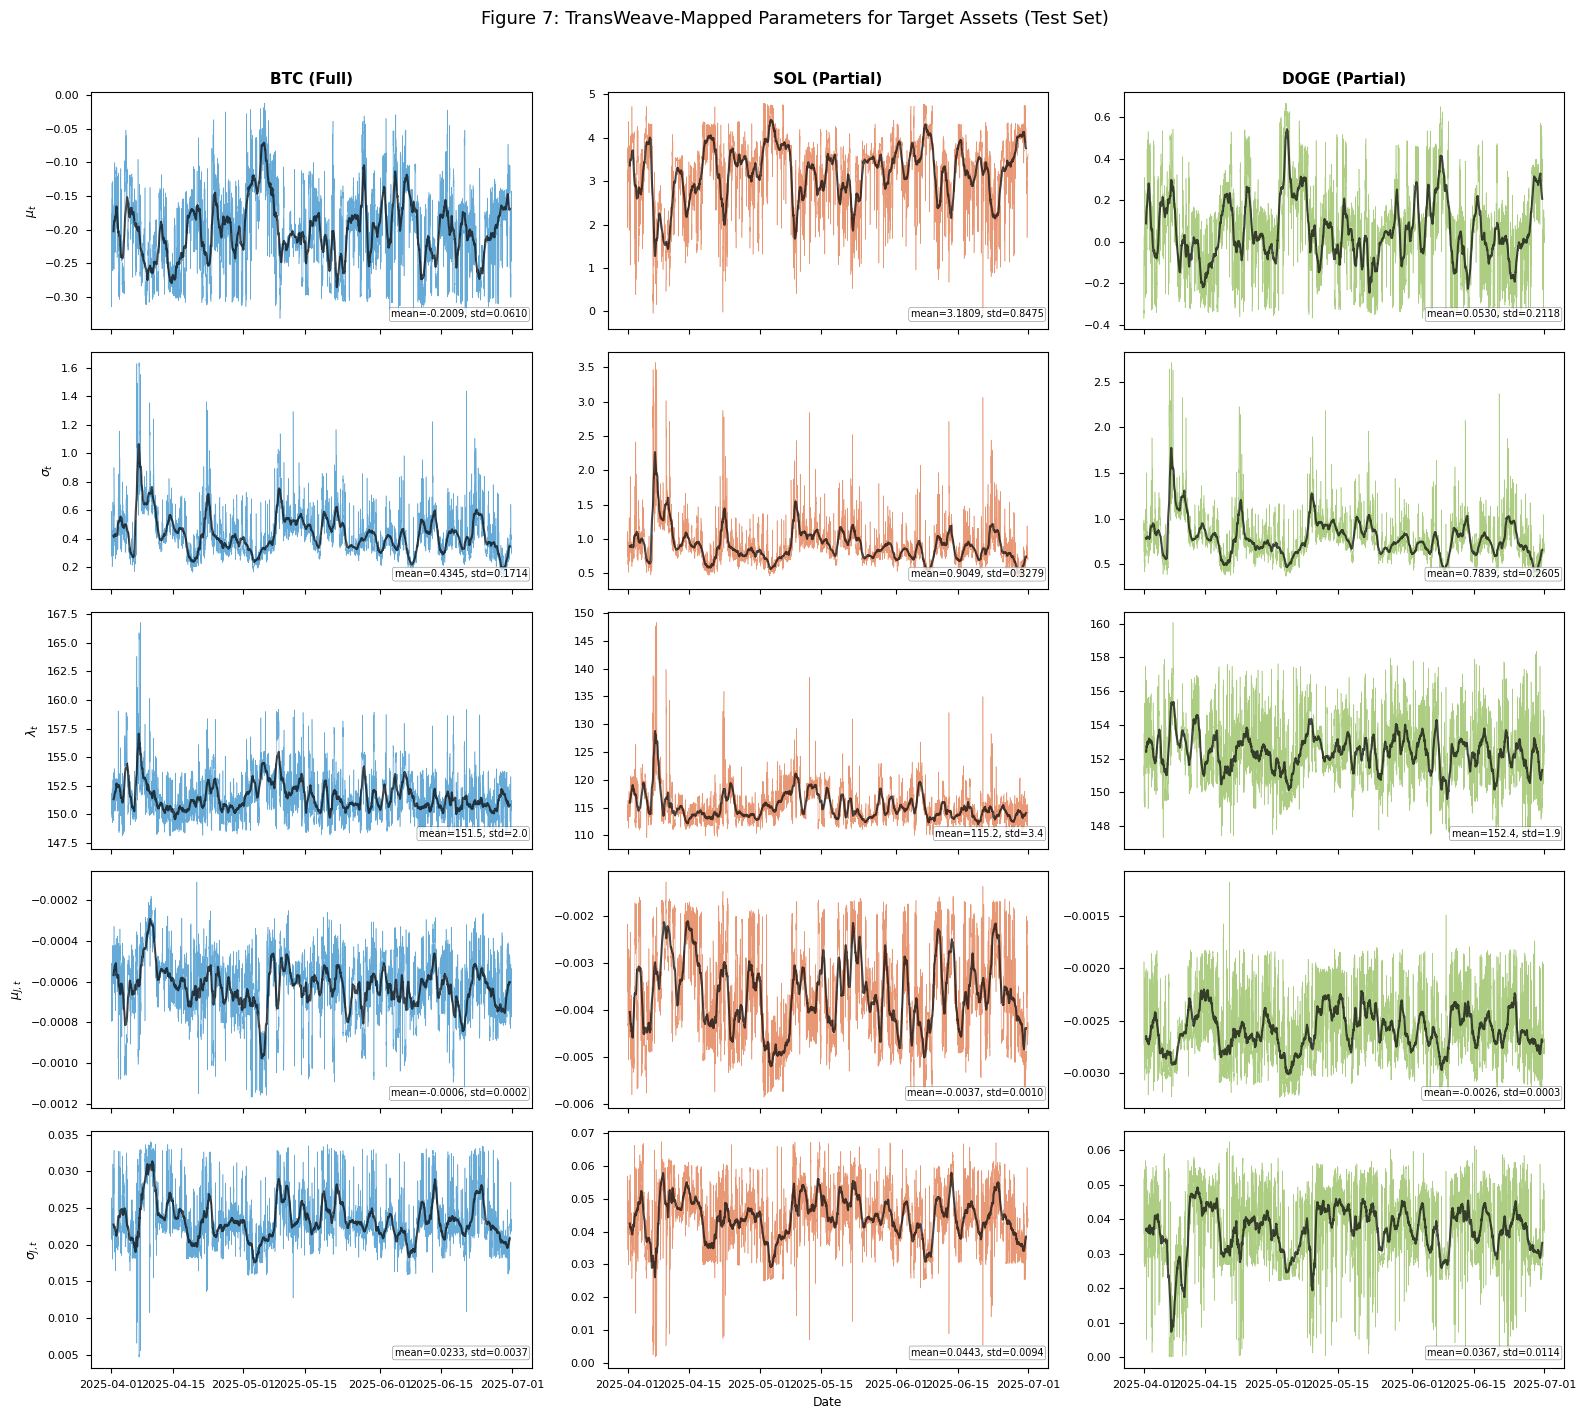

In [12]:
# ── Figure 7: Target Asset Parameters After TransWeave Transfer ──
import torch
import torch.nn.functional as F

# Load TransferMap architecture
class TransferMap(torch.nn.Module):
    def __init__(self, n_regimes=4, hidden_dim=64):
        super().__init__()
        input_dim = 5 + n_regimes
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim), torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, hidden_dim), torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, 5),
        )
        self.register_buffer("residual_scale", torch.ones(5) * 0.3)
        self.register_buffer("a_mean", torch.zeros(5))
        self.register_buffer("a_std", torch.ones(5))
        self.register_buffer("b_mean", torch.zeros(5))
        self.register_buffer("b_std", torch.ones(5))

    def forward(self, theta_a, regime_onehot):
        theta_a_norm = (theta_a - self.a_mean) / self.a_std
        x = torch.cat([theta_a_norm, regime_onehot], dim=-1)
        delta = self.net(x)
        theta_b_norm = theta_a_norm + self.residual_scale * delta
        theta_b = self.b_mean + self.b_std * theta_b_norm
        theta_b = torch.stack([
            theta_b[:, 0],
            F.softplus(theta_b[:, 1]),
            F.softplus(theta_b[:, 2]),
            theta_b[:, 3],
            F.softplus(theta_b[:, 4]),
        ], dim=-1)
        return theta_b

# Load ETH regime sequence (1h, upsampled to 15min)
regime_npz = np.load(ROOT / "experiments" / "checkpoints" / "regime_ETH.npz", allow_pickle=True)
regime_1h = regime_npz["state_sequence"]
regime_15min = np.repeat(regime_1h, 4)

# Get test-period regime
n_total = len(regime_15min)
n_test = len(theta_wp)
regime_test = regime_15min[n_total - n_test : n_total]
if len(regime_test) < n_test:
    regime_test = np.pad(regime_test, (0, n_test - len(regime_test)), mode="edge")
regime_test = regime_test[:n_test]

# One-hot encode
regime_oh = torch.zeros(n_test, 4)
for i in range(4):
    regime_oh[:, i] = torch.tensor((regime_test == i).astype(np.float32))

# ETH source theta
theta_a_t = torch.tensor(theta_wp, dtype=torch.float32)

# Run TransferMap for each target
target_params = {}
for target in ["BTC", "SOL", "DOGE"]:
    ckpt_path = CKPT / f"transfer_map_{target}.pt"
    if not ckpt_path.exists():
        print(f"  {target}: checkpoint not found, skipping")
        continue
    T_map = TransferMap()
    sd = torch.load(ckpt_path, map_location="cpu")
    T_map.load_state_dict(sd, strict=True)
    T_map.eval()
    with torch.no_grad():
        theta_b = T_map(theta_a_t, regime_oh).numpy()
    target_params[target] = theta_b
    # Debug: omit shape/lam print for clean report

# Plot: 5 rows (params) x 3 columns (targets)
param_labels = ["$\\mu_t$", "$\\sigma_t$", "$\\lambda_t$", "$\\mu_{J,t}$", "$\\sigma_{J,t}$"]
target_colors_list = {"BTC": "#0072BD", "SOL": "#D95319", "DOGE": "#77AC30"}

fig, axes = plt.subplots(5, 3, figsize=(16, 14), sharex=True)
for col, target in enumerate(["BTC", "SOL", "DOGE"]):
    if target not in target_params:
        continue
    theta_b = target_params[target]
    c = target_colors_list[target]
    for row in range(5):
        ax = axes[row, col]
        vals = theta_b[:, row]
        ax.plot(test_idx[:len(vals)], vals, lw=0.4, alpha=0.6, color=c)
        if len(vals) > 96:
            rolling = pd.Series(vals).rolling(96, center=True).mean()
            ax.plot(test_idx[:len(vals)], rolling, lw=1.5, color="black", alpha=0.7)
        if col == 0:
            ax.set_ylabel(param_labels[row], fontsize=9)
        if row == 0:
            ax.set_title(f"{target} ({s6[col]['decision'].capitalize()})",
                        fontsize=11, fontweight="bold")
        stats = f"mean={vals.mean():.4f}, std={vals.std():.4f}" if row != 2 else f"mean={vals.mean():.1f}, std={vals.std():.1f}"
        ax.text(0.99, 0.05, stats, transform=ax.transAxes, ha="right", fontsize=7,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))

axes[-1, 1].set_xlabel("Date")
fig.suptitle("Figure 7: TransWeave-Mapped Parameters for Target Assets (Test Set)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "report_fig7_target_params.png", dpi=DPI, bbox_inches="tight")
plt.show()


## 7.2 Diagnostic Observations

**ETH source model (Figure 6):**

- **σ\_t shows the most variation.** Diffusion volatility tracks market conditions well — spikes align with major price moves and elevated realized volatility.
- **λ\_t has limited variation.** Despite the W-finetune model having more λ variation than the base model (std ≈ 23 vs 0.5), the coefficient of variation is still modest (~9%). The model prefers adjusting σ\_t and σ\_{J,t} to fit changing conditions.
- **μ\_t and μ\_{J,t} cluster near zero.** Drift is small relative to volatility at 15-minute resolution, and the jump mean is slightly negative, reflecting the well-documented asymmetry of crypto jumps.

**Target asset parameters (Figure 7):**

The TransWeave-mapped parameters show how the transfer map adapts ETH's parameter dynamics to each target. Key observations:
- **BTC** parameters closely track ETH's shape (same temporal patterns) with modest level shifts — consistent with Full transfer mode and high ρ.
- **SOL** shows larger σ\_t values (reflecting its higher realized volatility) and more divergent λ\_t dynamics.
- **DOGE** parameters exhibit the most distinct levels but still preserve ETH's temporal structure through the regime conditioning.

## 7.3 Transfer Map Output Quality

For the transfer experiments, a key diagnostic is whether the mapped parameters $T(\theta^{(a)})$ produce well-calibrated return distributions on the target asset. We assess this through the full NLL + CRPS comparison:


In [13]:
# ── Table 5: Full Metric Comparison (NLL + CRPS) ──
rows = []
for r in s6:
    t = r["target_asset"]
    tft_nll = tgt_tft["target_tft_jd"][t]["nll"]
    tft_crps = tgt_tft["target_tft_jd"][t]["crps"]
    rows.append({
        "Target": t,
        "Mode": r["decision"].capitalize(),
        "": "",
        "Scratch NLL": f'{r["scratch"]["nll"]:.3f}',
        "TW NLL": f'{r["transweave"]["nll"]:.3f}',
        "Target-TFT NLL": f'{tft_nll:.3f}',
        " ": "",
        "Scratch CRPS": f'{r["scratch"]["crps"]:.5f}',
        "TW CRPS": f'{r["transweave"]["crps"]:.5f}',
        "Target-TFT CRPS": f'{tft_crps:.5f}',
    })
# Table shown in markdown cell above; omit print to avoid raw |---| in PDF export


**Table 5.** Complete test-set metrics (single-line format for PDF export):

| Target | Mode | Scratch NLL | TW NLL | Target-TFT NLL | Scratch CRPS | TW CRPS | Target-TFT CRPS |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **BTC** | Full | -4.788 | -4.860 | -4.888 | 0.00113 | 0.00110 | 0.00108 |
| **SOL** | Partial | -4.177 | -4.142 | -4.211 | 0.00217 | 0.00220 | 0.00213 |
| **DOGE** | Partial | -4.038 | -4.084 | -4.083 | 0.00245 | 0.00241 | 0.00239 |

**Table 5.** NLL and CRPS tell the same story: TransWeave improves both metrics for BTC and DOGE, underperforms on SOL. The CRPS improvements are proportionally larger than NLL improvements on DOGE — the transfer map produces a better-calibrated full distribution, not just a higher peak density.

For DOGE, TransWeave's CRPS (0.00241) is within a negligible margin of the target-only benchmark (Target-TFT CRPS 0.00239). This is notable because DOGE has the lowest regime overlap with ETH — the transfer map generalizes better than the raw $\rho_{\text{regime}}$ metric would predict.

---

# 8. Limitations & Future Work

## 8.1 Known Limitations

**1. Parameter-space simplification.** Our TransferMap operates in JD parameter space rather than the state-space Bellman–Darboux formulation described in the paper (Section 3). This design choice was motivated by computational tractability: a parameter-space regression $T(\theta^{(a)}, \text{regime}) \to \theta^{(b)}$ is straightforward to optimize, while a full state-space implementation would require paired feature inputs and additional architectural complexity. The trade-off is that the map cannot condition on target-asset features $X^{(b)}$ and relies entirely on source parameters and regime labels. A state-space extension could potentially improve performance on dissimilar targets like SOL.

**2. Limited asset coverage.** We test transfer on only three target assets, all cryptocurrencies. While BTC/SOL/DOGE span a range of market dynamics, three targets is a small sample for validating the transfer framework's generality. A larger-scale study — covering 10+ crypto assets, or extending to equities and forex — would better demonstrate the paper's potential for systematic cross-asset modeling.

**3. Feature set could be richer.** Our 14-feature input covers standard price-volume indicators and 4 on-chain metrics. The TFT is capable of ingesting many more features — order book depth, funding rates, cross-exchange spreads, sentiment indicators — that could improve both source model quality and transfer effectiveness. The current feature set was chosen for reproducibility, not optimality.

**4. Hyperparameter tuning was manual.** Key hyperparameters ($\lambda_{wpt}$, Phase 4 lr, L2 anchor weight) were tuned by manual iteration rather than systematic search (grid search, Bayesian optimization). The Phase 3/4 interaction (§6.4) was particularly sensitive — a more rigorous search over the joint ($\lambda_{wpt}^{\text{P3}}$, $\lambda_{wpt}^{\text{P4}}$, lr) space could yield better results, especially for the underperforming SOL target.

---

# 9. Conclusion

We have reproduced the core pipeline of Goertzel (2025) using cryptocurrency data: a Merton jump-diffusion model with time-varying parameters conditioned via a Temporal Fusion Transformer, a prospect-theory weakness regularizer, HMM-based regime detection with multi-factor transfer feasibility scoring, and a parameter-space TransWeave transfer map.

**Key findings:**

1. **TFT conditioning is the dominant contributor** to source model quality. The jump from Static-JD to TFT-JD (ΔNLL = −0.19) is 5× larger than adding the jump component itself (GBM → Static-JD, ΔNLL = −0.04). Time-varying parameters matter more than the parametric specification.

2. **TransWeave transfer works for 2 of 3 targets.** BTC (Δ = −0.072) and DOGE (Δ = −0.046) benefit from transfer; SOL (Δ = +0.035) does not. The composite S\_transfer score, computed before any training, correctly predicts this ordering.

3. **Unconstrained MLE pushes $\lambda$ to degenerate values** ($\lambda > 9000$ with $\sigma_J \to 0$). The empirical MAP prior resolves this for the static model; the W-finetune training mode further breaks the coupling in the neural setting, enabling meaningful temporal variation in $\lambda_t$.

4. **Weakness regularization has an unexpected dual role.** Beyond its intended purpose of behavioral robustness, the W-finetune mode uniquely produces a source model where $\lambda_t$ has meaningful temporal variation — an effect that neither the prior alone nor weakness-from-scratch achieves.

5. **The multi-factor decision framework works.** SOL's $\rho_{\text{regime}} = 0.714$ passes the Full threshold, but its $S_{\text{transfer}} = 0.391$ correctly triggers a downgrade to Partial mode, reflecting the genuine difficulty of transferring to an asset with 2× higher volatility.

This empirical implementation provides supportive evidence for the paper's central thesis: cross-asset transfer in parameter space is feasible when source and target share sufficient regime structure, and the multi-factor feasibility framework is directionally informative about which transfers will succeed in this three-target experiment.